In [1]:
# Setup

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

from pathlib import Path
import json
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
import torch.nn as nn

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/intentmap-nids/intentmap-nids"
)

DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
CONFIG_DIR = PROJECT_ROOT / "config"
RESULT_DIR = PROJECT_ROOT / "results" / "unsw"

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TEST_FILE = DATA_DIR / "test_full.npz"
VAL_FILE = DATA_DIR / "val_normal.npz"

print("UNSW test:", TEST_FILE.exists())
print("UNSW validation:", VAL_FILE.exists())
print("Result folder:", RESULT_DIR)

Mounted at /content/drive
UNSW test: True
UNSW validation: True
Result folder: /content/drive/MyDrive/intentmap-nids/intentmap-nids/results/unsw


In [2]:
# Load UNSW test and validation data

with np.load(TEST_FILE) as data:
    X_test = data["X"].astype(np.float32)
    y_test = data["y"].astype(np.int8)

with np.load(VAL_FILE) as data:
    X_val = data["X"].astype(np.float32)

print("Test X:", X_test.shape)
print("Test y:", y_test.shape)
print("Validation X:", X_val.shape)

print("Normal:", int((y_test == 0).sum()))
print("Attack:", int((y_test == 1).sum()))

print("NaN:", int(np.isnan(X_test).sum()))
print("Infinite:", int(np.isinf(X_test).sum()))

assert X_test.shape[1] == 41
assert X_val.shape[1] == 41
assert len(X_test) == len(y_test)
assert np.isfinite(X_test).all()

print("\nUNSW TEST DATA READY")

Test X: (82332, 41)
Test y: (82332,)
Validation X: (10266, 41)
Normal: 37000
Attack: 45332
NaN: 0
Infinite: 0

UNSW TEST DATA READY


In [3]:
# Model and configuration paths

IF_MODEL_FILE = (
    MODEL_DIR /
    "isolation_forest_candidate1.joblib"
)

AE_MODEL_FILE = (
    MODEL_DIR /
    "autoencoder_candidate1.keras"
)

LOF_MODEL_FILE = (
    MODEL_DIR /
    "lof_baseline.joblib"
)

OCSVM_MODEL_FILE = (
    MODEL_DIR /
    "ocsvm_model.joblib"
)

DEEP_MODEL_FILE = (
    MODEL_DIR /
    "deep_svdd_model.pt"
)

IF_CONFIG_FILE = (
    CONFIG_DIR /
    "isolation_forest_candidate1.json"
)

AE_CONFIG_FILE = (
    CONFIG_DIR /
    "autoencoder_candidate1.json"
)

LOF_CONFIG_FILE = (
    CONFIG_DIR /
    "lof_baseline.json"
)

OCSVM_CONFIG_FILE = (
    CONFIG_DIR /
    "ocsvm_model.json"
)

DEEP_CONFIG_FILE = (
    CONFIG_DIR /
    "deep_svdd_model.json"
)

HYBRID_CONFIG_FILE = (
    CONFIG_DIR /
    "hybrid_if_ae.json"
)

required_files = [
    IF_MODEL_FILE,
    AE_MODEL_FILE,
    LOF_MODEL_FILE,
    OCSVM_MODEL_FILE,
    DEEP_MODEL_FILE,
    IF_CONFIG_FILE,
    AE_CONFIG_FILE,
    LOF_CONFIG_FILE,
    OCSVM_CONFIG_FILE,
    DEEP_CONFIG_FILE,
    HYBRID_CONFIG_FILE
]

for file in required_files:
    print(
        file.name,
        "->",
        file.exists()
    )

if not all(
    file.exists()
    for file in required_files
):
    raise FileNotFoundError(
        "One or more model/config files are missing."
    )

isolation_forest_candidate1.joblib -> True
autoencoder_candidate1.keras -> True
lof_baseline.joblib -> True
ocsvm_model.joblib -> True
deep_svdd_model.pt -> True
isolation_forest_candidate1.json -> True
autoencoder_candidate1.json -> True
lof_baseline.json -> True
ocsvm_model.json -> True
deep_svdd_model.json -> True
hybrid_if_ae.json -> True


In [4]:
# Load thresholds

def load_json(path):
    with open(path, "r") as file:
        return json.load(file)

if_config = load_json(
    IF_CONFIG_FILE
)

ae_config = load_json(
    AE_CONFIG_FILE
)

lof_config = load_json(
    LOF_CONFIG_FILE
)

ocsvm_config = load_json(
    OCSVM_CONFIG_FILE
)

deep_config = load_json(
    DEEP_CONFIG_FILE
)

hybrid_config = load_json(
    HYBRID_CONFIG_FILE
)

BUDGETS = [
    "0.5% budget",
    "1% budget",
    "3% budget"
]

def get_thresholds(config):
    return {
        key: float(value)
        for key, value
        in config["thresholds"].items()
    }

if_thresholds = get_thresholds(
    if_config
)

ae_thresholds = get_thresholds(
    ae_config
)

lof_thresholds = get_thresholds(
    lof_config
)

ocsvm_thresholds = get_thresholds(
    ocsvm_config
)

deep_thresholds = get_thresholds(
    deep_config
)

hybrid_thresholds = get_thresholds(
    hybrid_config
)

print("IF:", if_thresholds)
print("AE:", ae_thresholds)
print("LOF:", lof_thresholds)
print("OCSVM:", ocsvm_thresholds)
print("Deep SVDD:", deep_thresholds)
print("Hybrid:", hybrid_thresholds)

IF: {'0.5% budget': 0.5676495685072951, '1% budget': 0.5460537691550149, '3% budget': 0.4966390963721801}
AE: {'0.5% budget': 0.04577401398215515, '1% budget': 0.036467666841251495, '3% budget': 0.02375445595651247}
LOF: {'0.5% budget': 1.9827458421041482, '1% budget': 1.8009945299909127, '3% budget': 1.476140406733413}
OCSVM: {'0.5% budget': 0.715225019931776, '1% budget': -5.3313550321087755e-05, '3% budget': -1.0914602100972197}
Deep SVDD: {'0.5% budget': 8.080383850028738e-05, '1% budget': 5.488995884661563e-05, '3% budget': 3.0722618248546496e-05}
Hybrid: {'0.5% budget': 0.9909942047336122, '1% budget': 0.9800818155254699, '3% budget': 0.9389378591604168}


In [5]:
# Load trained models

if_model = joblib.load(
    IF_MODEL_FILE
)

ae_model = tf.keras.models.load_model(
    AE_MODEL_FILE,
    compile=False
)

lof_model = joblib.load(
    LOF_MODEL_FILE
)

ocsvm_model = joblib.load(
    OCSVM_MODEL_FILE
)

print("Isolation Forest loaded")
print("Autoencoder loaded")
print("LOF loaded")
print("One-Class SVM loaded")

Isolation Forest loaded
Autoencoder loaded
LOF loaded
One-Class SVM loaded


In [6]:
# Scoring functions

def sklearn_scores(
    model,
    X,
    method,
    batch_size=20000
):
    scores = np.empty(
        len(X),
        dtype=np.float64
    )

    for start in range(
        0,
        len(X),
        batch_size
    ):
        end = min(
            start + batch_size,
            len(X)
        )

        batch = X[start:end]

        if method == "if":
            batch_scores = (
                -model.score_samples(batch)
            )

        elif method == "lof":
            batch_scores = (
                -model.score_samples(batch)
            )

        elif method == "ocsvm":
            batch_scores = (
                -model.decision_function(batch)
            )

        else:
            raise ValueError(
                "Unknown scoring method"
            )

        scores[start:end] = (
            np.asarray(batch_scores)
            .reshape(-1)
        )

    return scores


def autoencoder_scores(
    model,
    X,
    batch_size=1024
):
    scores = np.empty(
        len(X),
        dtype=np.float64
    )

    for start in range(
        0,
        len(X),
        batch_size
    ):
        end = min(
            start + batch_size,
            len(X)
        )

        batch = X[start:end]

        reconstructed = model.predict(
            batch,
            batch_size=batch_size,
            verbose=0
        )

        scores[start:end] = np.mean(
            np.square(
                batch - reconstructed
            ),
            axis=1
        )

    return scores


def percentile_normalize(
    reference_scores,
    scores
):
    reference_sorted = np.sort(
        np.asarray(reference_scores)
    )

    ranks = np.searchsorted(
        reference_sorted,
        scores,
        side="right"
    )

    return (
        ranks /
        (len(reference_sorted) + 1)
    )

In [7]:
# Isolation Forest scores

print("Scoring Isolation Forest...")

if_val_scores = sklearn_scores(
    if_model,
    X_val,
    method="if"
)

if_test_scores = sklearn_scores(
    if_model,
    X_test,
    method="if"
)

print("Validation:", if_val_scores.shape)
print("Test:", if_test_scores.shape)
print("Done")

Scoring Isolation Forest...
Validation: (10266,)
Test: (82332,)
Done


In [8]:
# Autoencoder scores

print("Scoring Autoencoder...")

ae_val_scores = autoencoder_scores(
    ae_model,
    X_val
)

ae_test_scores = autoencoder_scores(
    ae_model,
    X_test
)

print("Validation:", ae_val_scores.shape)
print("Test:", ae_test_scores.shape)
print("Done")

Scoring Autoencoder...
Validation: (10266,)
Test: (82332,)
Done


In [9]:
# LOF scores

print("Scoring LOF...")

lof_test_scores = sklearn_scores(
    lof_model,
    X_test,
    method="lof"
)

print("Test:", lof_test_scores.shape)
print("Done")

Scoring LOF...
Test: (82332,)
Done


In [10]:
# One-Class SVM scores

print("Scoring One-Class SVM...")

ocsvm_test_scores = sklearn_scores(
    ocsvm_model,
    X_test,
    method="ocsvm"
)

print("Test:", ocsvm_test_scores.shape)
print("Done")

Scoring One-Class SVM...
Test: (82332,)
Done


In [11]:
# Deep SVDD

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

class DeepSVDDNet(nn.Module):
    def __init__(
        self,
        input_dim,
        representation_dim=16
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_dim,
                64,
                bias=False
            ),
            nn.ReLU(),
            nn.Linear(
                64,
                32,
                bias=False
            ),
            nn.ReLU(),
            nn.Linear(
                32,
                representation_dim,
                bias=False
            )
        )

    def forward(self, x):
        return self.network(x)


checkpoint = torch.load(
    DEEP_MODEL_FILE,
    map_location=DEVICE,
    weights_only=False
)

deep_model = DeepSVDDNet(
    input_dim=int(
        checkpoint["input_dim"]
    ),
    representation_dim=int(
        checkpoint["representation_dim"]
    )
).to(DEVICE)

deep_model.load_state_dict(
    checkpoint["model_state_dict"]
)

deep_model.eval()

deep_center = torch.tensor(
    checkpoint["center"],
    dtype=torch.float32,
    device=DEVICE
)

print("Deep SVDD loaded")
print("Device:", DEVICE)

Deep SVDD loaded
Device: cpu


In [12]:
# Score Deep SVDD

def deep_svdd_scores(
    model,
    X,
    center,
    device,
    batch_size=4096
):
    scores = np.empty(
        len(X),
        dtype=np.float64
    )

    for start in range(
        0,
        len(X),
        batch_size
    ):
        end = min(
            start + batch_size,
            len(X)
        )

        batch = torch.tensor(
            X[start:end],
            dtype=torch.float32,
            device=device
        )

        with torch.no_grad():
            output = model(batch)

            distances = torch.sum(
                (output - center) ** 2,
                dim=1
            )

        scores[start:end] = (
            distances
            .cpu()
            .numpy()
        )

    return scores


print("Scoring Deep SVDD...")

deep_test_scores = deep_svdd_scores(
    deep_model,
    X_test,
    deep_center,
    DEVICE
)

print("Test:", deep_test_scores.shape)
print("Done")

Scoring Deep SVDD...
Test: (82332,)
Done


In [13]:
# Hybrid IF + AE scores

if_val_norm = percentile_normalize(
    if_val_scores,
    if_val_scores
)

if_test_norm = percentile_normalize(
    if_val_scores,
    if_test_scores
)

ae_val_norm = percentile_normalize(
    ae_val_scores,
    ae_val_scores
)

ae_test_norm = percentile_normalize(
    ae_val_scores,
    ae_test_scores
)

IF_WEIGHT = float(
    hybrid_config["if_weight"]
)

AE_WEIGHT = float(
    hybrid_config["ae_weight"]
)

hybrid_val_scores = (
    IF_WEIGHT * if_val_norm
    +
    AE_WEIGHT * ae_val_norm
)

hybrid_test_scores = (
    IF_WEIGHT * if_test_norm
    +
    AE_WEIGHT * ae_test_norm
)

print("IF weight:", IF_WEIGHT)
print("AE weight:", AE_WEIGHT)

print(
    "Hybrid test range:",
    hybrid_test_scores.min(),
    hybrid_test_scores.max()
)

IF weight: 0.5
AE weight: 0.5
Hybrid test range: 0.0038472776857894223 0.9999026005649168


In [14]:
# Check all scores

score_arrays = {
    "Isolation Forest": if_test_scores,
    "Autoencoder": ae_test_scores,
    "Hybrid IF+AE": hybrid_test_scores,
    "LOF": lof_test_scores,
    "One-Class SVM": ocsvm_test_scores,
    "Deep SVDD": deep_test_scores
}

for name, scores in score_arrays.items():
    print(
        name,
        "records:",
        len(scores),
        "finite:",
        np.isfinite(scores).all()
    )

    assert len(scores) == len(y_test)
    assert np.isfinite(scores).all()

print("\nALL SCORES READY")

Isolation Forest records: 82332 finite: True
Autoencoder records: 82332 finite: True
Hybrid IF+AE records: 82332 finite: True
LOF records: 82332 finite: True
One-Class SVM records: 82332 finite: True
Deep SVDD records: 82332 finite: True

ALL SCORES READY


In [15]:
# Evaluation function

def evaluate_model(
    model_name,
    scores,
    thresholds
):
    rows = []

    roc_auc = roc_auc_score(
        y_test,
        scores
    )

    pr_auc = average_precision_score(
        y_test,
        scores
    )

    for budget in BUDGETS:
        threshold = float(
            thresholds[budget]
        )

        predictions = (
            scores >= threshold
        ).astype(np.int8)

        tn, fp, fn, tp = confusion_matrix(
            y_test,
            predictions,
            labels=[0, 1]
        ).ravel()

        precision = precision_score(
            y_test,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            predictions,
            zero_division=0
        )

        fpr = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else 0
        )

        rows.append({
            "Model": model_name,
            "Budget": budget,
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "FPR": fpr,
            "False alerts per 1000": fpr * 1000,
            "ROC-AUC": roc_auc,
            "PR-AUC": pr_auc,
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp)
        })

    return pd.DataFrame(rows)

In [16]:
# Evaluate all six models

if_results = evaluate_model(
    "Isolation Forest",
    if_test_scores,
    if_thresholds
)

ae_results = evaluate_model(
    "Dense Autoencoder",
    ae_test_scores,
    ae_thresholds
)

hybrid_results = evaluate_model(
    "Hybrid IF+AE",
    hybrid_test_scores,
    hybrid_thresholds
)

lof_results = evaluate_model(
    "LOF",
    lof_test_scores,
    lof_thresholds
)

ocsvm_results = evaluate_model(
    "One-Class SVM",
    ocsvm_test_scores,
    ocsvm_thresholds
)

deep_results = evaluate_model(
    "Deep SVDD",
    deep_test_scores,
    deep_thresholds
)

all_results = pd.concat(
    [
        if_results,
        ae_results,
        hybrid_results,
        lof_results,
        ocsvm_results,
        deep_results
    ],
    ignore_index=True
)

pd.set_option(
    "display.max_columns",
    None
)

display(all_results)

,Model,Budget,Threshold,Precision,Recall,F1,FPR,False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Isolation Forest,0.5% budget,0.567650,0.949434,0.608863,0.741932,0.039730,39.729730,0.851001,0.897443,35530,1470,17731,27601
1,Isolation Forest,1% budget,0.546054,0.940079,0.617070,0.745072,0.048189,48.189189,0.851001,0.897443,35217,1783,17359,27973
2,Isolation Forest,3% budget,0.496639,0.905033,0.663681,0.765791,0.085324,85.324324,0.851001,0.897443,33843,3157,15246,30086
3,Dense Autoencoder,0.5% budget,0.045774,0.947172,0.588525,0.725969,0.040216,40.216216,0.878460,0.901098,35512,1488,18653,26679
4,Dense Autoencoder,1% budget,0.036468,0.936372,0.632710,0.755157,0.052676,52.675676,0.878460,0.901098,35051,1949,16650,28682
5,Dense Autoencoder,3% budget,0.023754,0.912602,0.673983,0.775349,0.079081,79.081081,0.878460,0.901098,34074,2926,14779,30553
6,Hybrid IF+AE,0.5% budget,0.990994,0.954243,0.612768,0.746299,0.036000,36.000000,0.876671,0.905663,35668,1332,17554,27778
7,Hybrid IF+AE,1% budget,0.980082,0.943977,0.625938,0.752742,0.045514,45.513514,0.876671,0.905663,35316,1684,16957,28375
8,Hybrid IF+AE,3% budget,0.938938,0.911084,0.679233,0.778258,0.081216,81.216216,0.876671,0.905663,33995,3005,14541,30791
9,LOF,0.5% budget,1.982746,0.931963,0.344172,0.502698,0.030784,30.783784,0.897510,0.888702,35861,1139,29730,15602


In [17]:
# Final 1% comparison

comparison_1pct = (
    all_results[
        all_results["Budget"]
        == "1% budget"
    ]
    .copy()
)

comparison_1pct["FPR (%)"] = (
    comparison_1pct["FPR"] * 100
)

comparison_1pct = comparison_1pct[
    [
        "Model",
        "Precision",
        "Recall",
        "F1",
        "FPR (%)",
        "False alerts per 1000",
        "ROC-AUC",
        "PR-AUC",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

comparison_1pct = (
    comparison_1pct
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)

print("UNSW-NB15 FINAL MODEL COMPARISON")
print("Operating point: 1% budget")

display(comparison_1pct)

UNSW-NB15 FINAL MODEL COMPARISON
Operating point: 1% budget


,Model,Precision,Recall,F1,FPR (%),False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Dense Autoencoder,0.936372,0.632710,0.755157,5.267568,52.675676,0.878460,0.901098,35051,1949,16650,28682
1,Hybrid IF+AE,0.943977,0.625938,0.752742,4.551351,45.513514,0.876671,0.905663,35316,1684,16957,28375
2,Isolation Forest,0.940079,0.617070,0.745072,4.818919,48.189189,0.851001,0.897443,35217,1783,17359,27973
3,Deep SVDD,0.927429,0.594547,0.724584,5.700000,57.000000,0.887058,0.895507,34891,2109,18380,26952
4,LOF,0.936416,0.522721,0.670923,4.348649,43.486486,0.897510,0.888702,35391,1609,21636,23696
5,One-Class SVM,0.893863,0.339606,0.492207,4.940541,49.405405,0.794280,0.837517,35172,1828,29937,15395


In [18]:
# Create 1% predictions

if_pred = (
    if_test_scores
    >= if_thresholds["1% budget"]
).astype(np.int8)

ae_pred = (
    ae_test_scores
    >= ae_thresholds["1% budget"]
).astype(np.int8)

hybrid_pred = (
    hybrid_test_scores
    >= hybrid_thresholds["1% budget"]
).astype(np.int8)

lof_pred = (
    lof_test_scores
    >= lof_thresholds["1% budget"]
).astype(np.int8)

ocsvm_pred = (
    ocsvm_test_scores
    >= ocsvm_thresholds["1% budget"]
).astype(np.int8)

deep_pred = (
    deep_test_scores
    >= deep_thresholds["1% budget"]
).astype(np.int8)

print("1% predictions created")

1% predictions created


In [19]:
# Save record-level results

record_results = pd.DataFrame({
    "record_id":
        np.arange(len(y_test)),

    "actual_label":
        y_test,

    "if_score":
        if_test_scores,

    "if_prediction":
        if_pred,

    "ae_score":
        ae_test_scores,

    "ae_prediction":
        ae_pred,

    "hybrid_score":
        hybrid_test_scores,

    "hybrid_prediction":
        hybrid_pred,

    "lof_score":
        lof_test_scores,

    "lof_prediction":
        lof_pred,

    "ocsvm_score":
        ocsvm_test_scores,

    "ocsvm_prediction":
        ocsvm_pred,

    "deep_svdd_score":
        deep_test_scores,

    "deep_svdd_prediction":
        deep_pred
})

RECORD_FILE = (
    RESULT_DIR /
    "UNSW_Record_Level_Predictions.csv"
)

record_results.to_csv(
    RECORD_FILE,
    index=False
)

print("Saved:")
print(RECORD_FILE)

Saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/unsw/UNSW_Record_Level_Predictions.csv


In [20]:
# Save Excel and CSV results

REPORT_TABLE = comparison_1pct.copy()

numeric_columns = [
    "Precision",
    "Recall",
    "F1",
    "FPR (%)",
    "False alerts per 1000",
    "ROC-AUC",
    "PR-AUC"
]

for column in numeric_columns:
    REPORT_TABLE[column] = (
        REPORT_TABLE[column]
        .round(4)
    )

EXCEL_FILE = (
    RESULT_DIR /
    "UNSW_Model_Evaluation.xlsx"
)

CSV_FILE = (
    RESULT_DIR /
    "UNSW_Model_Comparison_1pct.csv"
)

with pd.ExcelWriter(
    EXCEL_FILE
) as writer:

    REPORT_TABLE.to_excel(
        writer,
        sheet_name="1pct Comparison",
        index=False
    )

    all_results.to_excel(
        writer,
        sheet_name="All Budgets",
        index=False
    )

REPORT_TABLE.to_csv(
    CSV_FILE,
    index=False
)

print("Excel:")
print(EXCEL_FILE)

print("\nCSV:")
print(CSV_FILE)

display(REPORT_TABLE)

Excel:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/unsw/UNSW_Model_Evaluation.xlsx

CSV:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/unsw/UNSW_Model_Comparison_1pct.csv


,Model,Precision,Recall,F1,FPR (%),False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Dense Autoencoder,0.9364,0.6327,0.7552,5.2676,52.6757,0.8785,0.9011,35051,1949,16650,28682
1,Hybrid IF+AE,0.9440,0.6259,0.7527,4.5514,45.5135,0.8767,0.9057,35316,1684,16957,28375
2,Isolation Forest,0.9401,0.6171,0.7451,4.8189,48.1892,0.8510,0.8974,35217,1783,17359,27973
3,Deep SVDD,0.9274,0.5945,0.7246,5.7000,57.0000,0.8871,0.8955,34891,2109,18380,26952
4,LOF,0.9364,0.5227,0.6709,4.3486,43.4865,0.8975,0.8887,35391,1609,21636,23696
5,One-Class SVM,0.8939,0.3396,0.4922,4.9405,49.4054,0.7943,0.8375,35172,1828,29937,15395


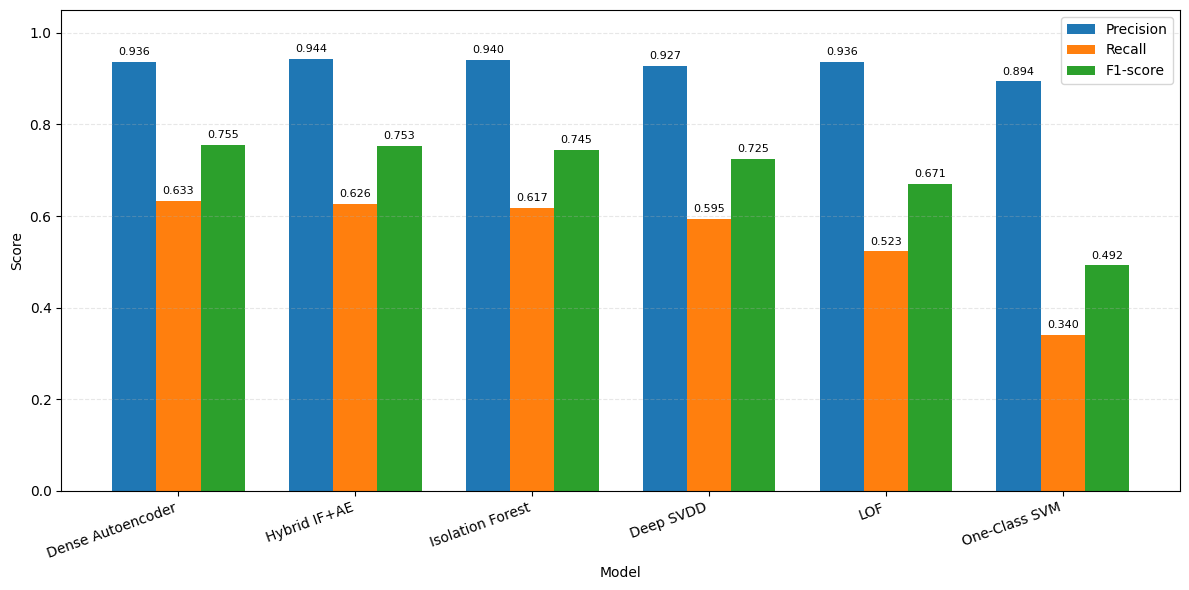

Saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/unsw/UNSW_Model_Performance_Bar_Chart.png


In [21]:
# Precision Recall F1 bar chart

chart_data = comparison_1pct.copy()

models = (
    chart_data["Model"]
    .tolist()
)

precision = (
    chart_data["Precision"]
    .to_numpy()
)

recall = (
    chart_data["Recall"]
    .to_numpy()
)

f1 = (
    chart_data["F1"]
    .to_numpy()
)

x = np.arange(
    len(models)
)

width = 0.25

plt.figure(
    figsize=(12, 6)
)

bars1 = plt.bar(
    x - width,
    precision,
    width,
    label="Precision"
)

bars2 = plt.bar(
    x,
    recall,
    width,
    label="Recall"
)

bars3 = plt.bar(
    x + width,
    f1,
    width,
    label="F1-score"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(
    x,
    models,
    rotation=20,
    ha="right"
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bars in [
    bars1,
    bars2,
    bars3
]:
    for bar in bars:
        value = bar.get_height()

        plt.text(
            bar.get_x()
            + bar.get_width() / 2,
            value + 0.015,
            f"{value:.3f}",
            ha="center",
            fontsize=8
        )

plt.tight_layout()

BAR_CHART_FILE = (
    RESULT_DIR /
    "UNSW_Model_Performance_Bar_Chart.png"
)

plt.savefig(
    BAR_CHART_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(BAR_CHART_FILE)

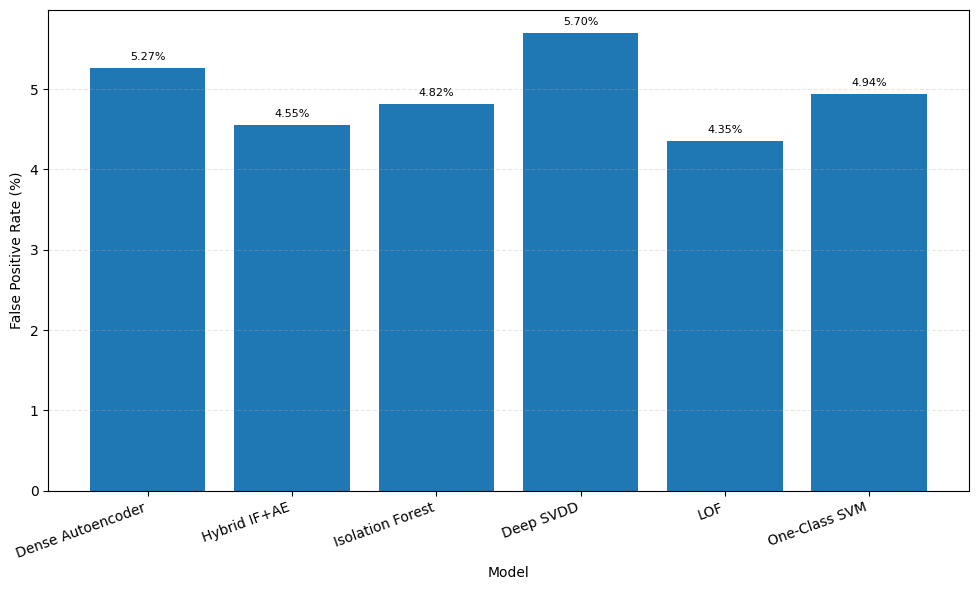

Saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/unsw/UNSW_Model_FPR_Bar_Chart.png


In [22]:
# False positive rate bar chart

fpr_data = comparison_1pct.copy()

plt.figure(
    figsize=(10, 6)
)

bars = plt.bar(
    fpr_data["Model"],
    fpr_data["FPR (%)"]
)

plt.xlabel("Model")
plt.ylabel("False Positive Rate (%)")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar, value in zip(
    bars,
    fpr_data["FPR (%)"]
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        value + 0.1,
        f"{value:.2f}%",
        ha="center",
        fontsize=8
    )

plt.tight_layout()

FPR_CHART_FILE = (
    RESULT_DIR /
    "UNSW_Model_FPR_Bar_Chart.png"
)

plt.savefig(
    FPR_CHART_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(FPR_CHART_FILE)

In [23]:
# Save score arrays

SCORES_FILE = (
    RESULT_DIR /
    "UNSW_All_Model_Scores_Predictions.npz"
)

np.savez_compressed(
    SCORES_FILE,
    y=y_test,

    if_score=if_test_scores,
    if_prediction=if_pred,

    ae_score=ae_test_scores,
    ae_prediction=ae_pred,

    hybrid_score=hybrid_test_scores,
    hybrid_prediction=hybrid_pred,

    lof_score=lof_test_scores,
    lof_prediction=lof_pred,

    ocsvm_score=ocsvm_test_scores,
    ocsvm_prediction=ocsvm_pred,

    deep_svdd_score=deep_test_scores,
    deep_svdd_prediction=deep_pred
)

print("Saved:")
print(SCORES_FILE)

Saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/unsw/UNSW_All_Model_Scores_Predictions.npz


In [24]:
# Final verification

assert len(record_results) == len(y_test)

assert np.isfinite(
    if_test_scores
).all()

assert np.isfinite(
    ae_test_scores
).all()

assert np.isfinite(
    hybrid_test_scores
).all()

assert np.isfinite(
    lof_test_scores
).all()

assert np.isfinite(
    ocsvm_test_scores
).all()

assert np.isfinite(
    deep_test_scores
).all()

print("UNSW-NB15 FINAL VERIFICATION")
print("Test records:", len(y_test))
print("Normal:", int((y_test == 0).sum()))
print("Attack:", int((y_test == 1).sum()))

print(
    "\nALL SIX MODELS TESTED SUCCESSFULLY"
)

display(
    comparison_1pct
)

UNSW-NB15 FINAL VERIFICATION
Test records: 82332
Normal: 37000
Attack: 45332

ALL SIX MODELS TESTED SUCCESSFULLY


,Model,Precision,Recall,F1,FPR (%),False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Dense Autoencoder,0.936372,0.632710,0.755157,5.267568,52.675676,0.878460,0.901098,35051,1949,16650,28682
1,Hybrid IF+AE,0.943977,0.625938,0.752742,4.551351,45.513514,0.876671,0.905663,35316,1684,16957,28375
2,Isolation Forest,0.940079,0.617070,0.745072,4.818919,48.189189,0.851001,0.897443,35217,1783,17359,27973
3,Deep SVDD,0.927429,0.594547,0.724584,5.700000,57.000000,0.887058,0.895507,34891,2109,18380,26952
4,LOF,0.936416,0.522721,0.670923,4.348649,43.486486,0.897510,0.888702,35391,1609,21636,23696
5,One-Class SVM,0.893863,0.339606,0.492207,4.940541,49.405405,0.794280,0.837517,35172,1828,29937,15395


In [25]:
# Create ZIP and download

from google.colab import files

ZIP_FILE = (
    RESULT_DIR /
    "UNSW_Final_Testing_Results.zip"
)

files_to_zip = [
    EXCEL_FILE,
    CSV_FILE,
    RECORD_FILE,
    SCORES_FILE,
    BAR_CHART_FILE,
    FPR_CHART_FILE
]

with zipfile.ZipFile(
    ZIP_FILE,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for file in files_to_zip:
        zip_file.write(
            file,
            arcname=file.name
        )

print("ZIP created:")
print(ZIP_FILE)

files.download(
    str(ZIP_FILE)
)

ZIP created:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/unsw/UNSW_Final_Testing_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>